In [1]:
from acceptor_TI import Problem

data_path = "../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
location = "edge"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


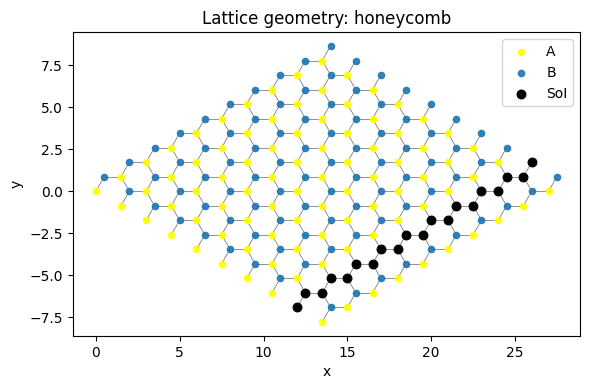

In [3]:
tb = problem.hamiltonian["edge"]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
    )

In [4]:
problem.geometry.T

array([ 1.5      , -0.8660254])

In [5]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


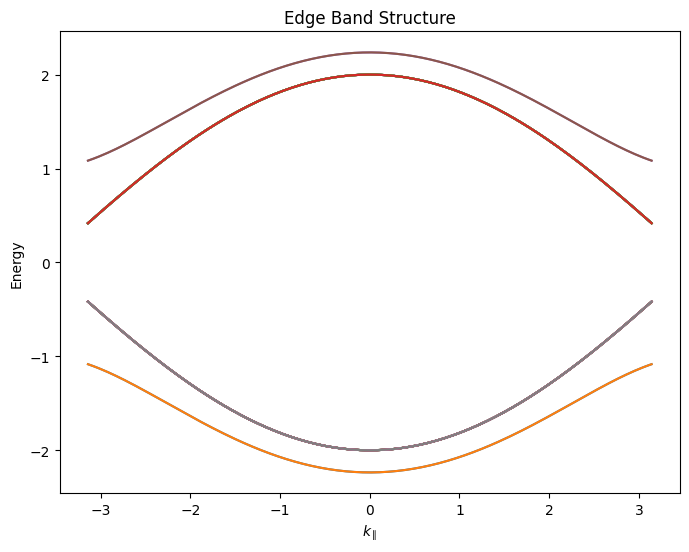

In [6]:
problem.plot(plot_type="dispersion", location=location)

In [7]:
hopping_dict = problem.cell_parser.eigenvalues.nn_hopping.value
hopping_dict["t_ss_sigma"] = -1.4
hopping_dict["t_sp_sigma"] = 1
hopping_dict["t_pp_sigma"] = 1
hopping_dict["t_pp_pi"] = -0.5

In [8]:
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [9]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


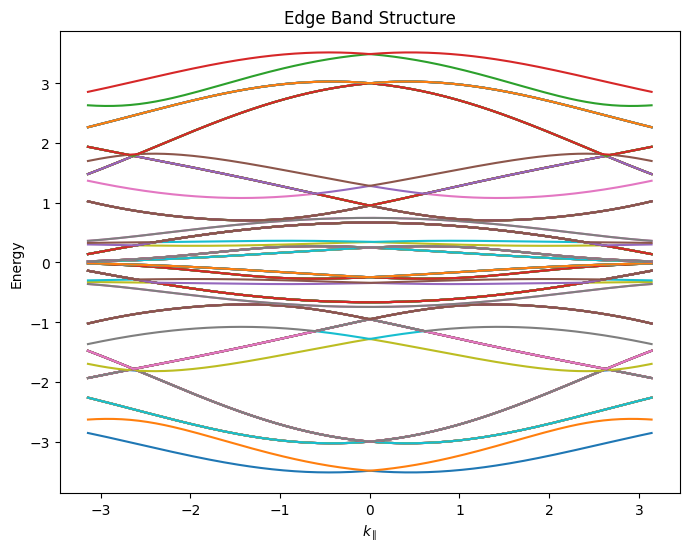

In [10]:
problem.plot(plot_type="dispersion", location=location)

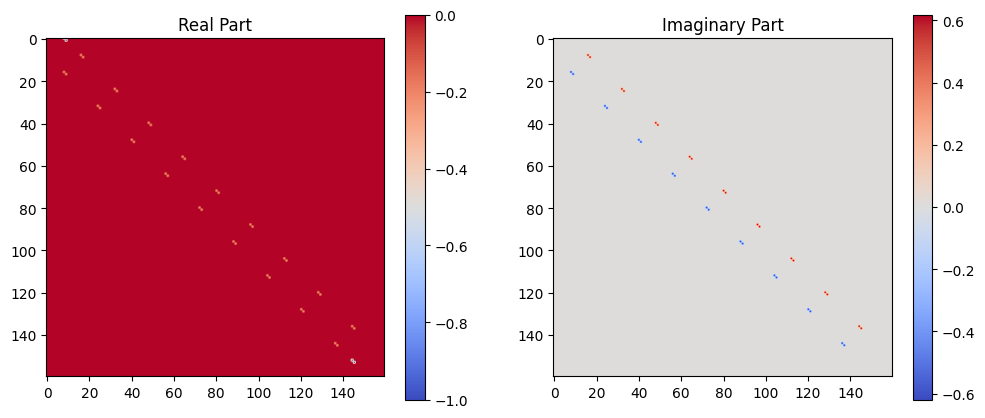

In [11]:
g = problem.geometry
k = g.k_edge[g.N_r-1]
H_k = tb._fourier_transform(k, g.T_hat)
tb._visualise_matrix(H_k)